## Task 1

### Loading the files

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
import pandas as pd

order_metadata = pd.read_csv("order_metadata.csv")
order_items__train = pd.read_csv("order_items__train.csv")
product_catalog = pd.read_csv("product_catalog.csv")
department_info = pd.read_csv("department_info.csv")
aisle_info = pd.read_csv("aisle_info.csv")
order_items__prior = pd.read_csv("order_items__prior.csv")

order_metadata

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
...,...,...,...,...,...,...,...
3421078,2266710,206209,prior,10,5,18,29.0
3421079,1854736,206209,prior,11,4,10,30.0
3421080,626363,206209,prior,12,1,12,18.0
3421081,2977660,206209,prior,13,1,12,7.0


In [3]:
order_items__prior

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
...,...,...,...,...
32434484,3421083,39678,6,1
32434485,3421083,11352,7,0
32434486,3421083,4600,8,0
32434487,3421083,24852,9,1


In [4]:
order_items__train

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1
...,...,...,...,...
1384612,3421063,14233,3,1
1384613,3421063,35548,4,1
1384614,3421070,35951,1,1
1384615,3421070,16953,2,1


In [5]:
product_catalog

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49683,49684,"Vodka, Triple Distilled, Twist of Vanilla",124,5
49684,49685,En Croute Roast Hazelnut Cranberry,42,1
49685,49686,Artisan Baguette,112,3
49686,49687,Smartblend Healthy Metabolism Dry Cat Food,41,8


In [6]:
department_info

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [7]:
aisle_info

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
...,...,...
129,130,hot cereal pancake mixes
130,131,dry pasta
131,132,beauty
132,133,muscles joints pain relief


### 1. Total number of orders and unique customers

In [8]:
total_orders = order_metadata['order_id'].nunique()
total_customers = order_metadata['user_id'].nunique()

In [9]:
total_orders

3421083

In [10]:
total_customers

206209

#### Merging the files product_catalog.csv, department_info.csv and aisle_info.csv for better analysis

In [11]:
merged_product_info = pd.merge(product_catalog, department_info, on = 'department_id')

In [12]:
merged_product_info = pd.merge(merged_product_info, aisle_info, on = 'aisle_id')

In [13]:
merged_product_info

,product_id,product_name,aisle_id,department_id,department,aisle
0,1,Chocolate Sandwich Cookies,61,19,snacks,cookies cakes
1,2,All-Seasons Salt,104,13,pantry,spices seasonings
2,3,Robust Golden Unsweetened Oolong Tea,94,7,beverages,tea
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen,frozen meals
4,5,Green Chile Anytime Sauce,5,13,pantry,marinades meat preparation
...,...,...,...,...,...,...
49683,49684,"Vodka, Triple Distilled, Twist of Vanilla",124,5,alcohol,spirits
49684,49685,En Croute Roast Hazelnut Cranberry,42,1,frozen,frozen vegan vegetarian
49685,49686,Artisan Baguette,112,3,bakery,bread
49686,49687,Smartblend Healthy Metabolism Dry Cat Food,41,8,pets,cat food care


Total unique products = 49688,
Total unique aisles = 134,
Total unique departments = 21

### 2. Number of unique products, aisles and departments

In [14]:
n_products = merged_product_info["product_id"].nunique()
n_aisles = merged_product_info["aisle_id"].nunique()
n_departments = merged_product_info["department_id"].nunique()

print(f"Unique Products: {n_products}")
print(f"Unique Aisles: {n_aisles}")
print(f"Unique Departments: {n_departments}")

Unique Products: 49688
Unique Aisles: 134
Unique Departments: 21


### 3. Top 20 most frequently ordered products

In [15]:
top_products = (
    order_items__prior['product_id']
    .value_counts()
    .rename_axis('product_id')
    .reset_index(name='count')
)
top_products = top_products.merge(
    merged_product_info[['product_id', 'product_name']],
    on='product_id',
    how='left'
)
top_products.head(20)

,product_id,count,product_name
0,24852,472565,Banana
1,13176,379450,Bag of Organic Bananas
2,21137,264683,Organic Strawberries
3,21903,241921,Organic Baby Spinach
4,47209,213584,Organic Hass Avocado
5,47766,176815,Organic Avocado
6,47626,152657,Large Lemon
7,16797,142951,Strawberries
8,26209,140627,Limes
9,27845,137905,Organic Whole Milk


### 4. Top departments and aisles by order volume

In [16]:
top_products_dept = top_products.merge(
    merged_product_info[['product_id', 'department']],
    on='product_id',
    how='left'
)

In [17]:
top_departments = (
    top_products_dept
    .groupby('department', dropna=False)['count']
    .sum()
    .reset_index()
    .sort_values('count', ascending=False).reset_index().drop('index', axis=1)
)
display(top_departments.head())

,department,count
0,produce,9479291
1,dairy eggs,5414016
2,snacks,2887550
3,beverages,2690129
4,frozen,2236432


In [18]:
top_products_aisle = top_products.merge(merged_product_info[['product_id', 'aisle']],on='product_id')

In [19]:
top_aisle = (
    top_products_aisle
    .groupby('aisle', dropna=False)['count']
    .sum()
    .reset_index()
    .sort_values('count', ascending=False).reset_index().drop('index', axis=1)
)
top_aisle.head()

,aisle,count
0,fresh fruits,3642188
1,fresh vegetables,3418021
2,packaged vegetables fruits,1765313
3,yogurt,1452343
4,packaged cheese,979763


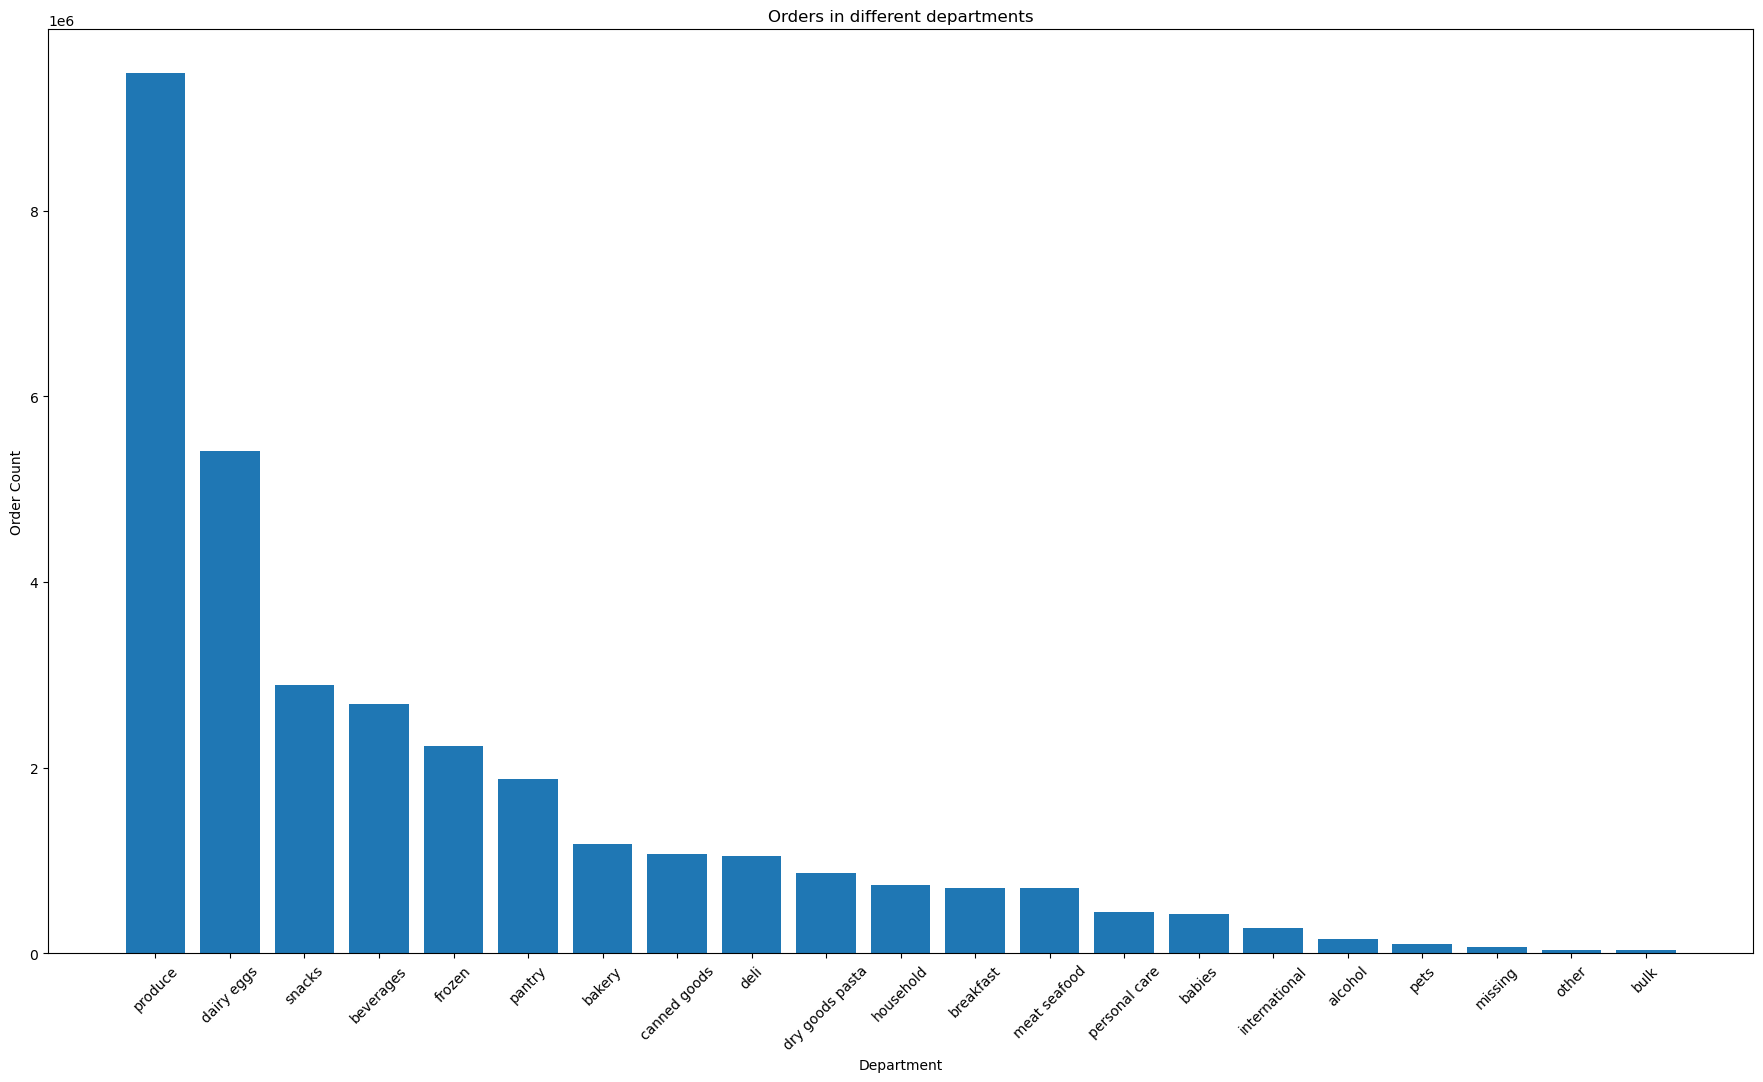

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(22, 12))
ax.bar(top_departments['department'], top_departments['count'])
ax.set_xlabel('Department')
ax.set_ylabel('Order Count')
ax.set_title('Orders in different departments')
ax.tick_params(axis='x', rotation = 45)
plt.show()

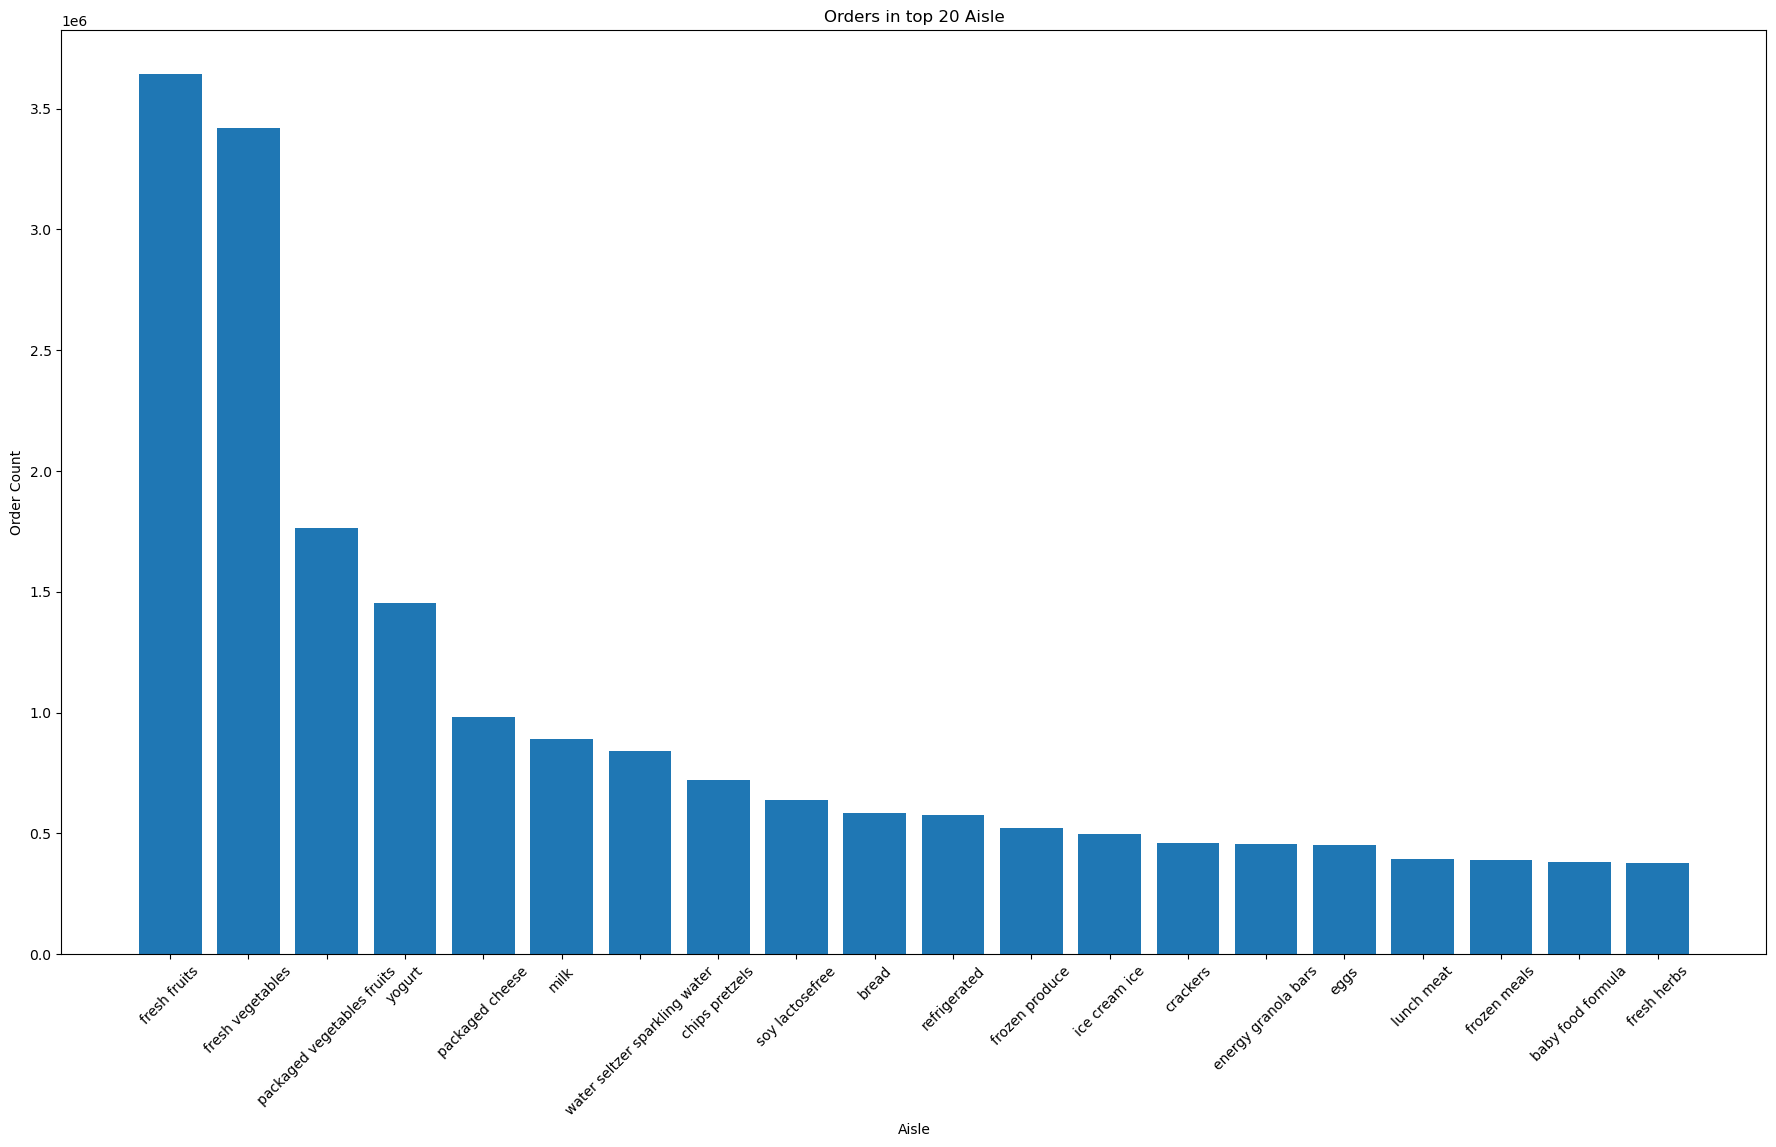

In [21]:
fig, ax = plt.subplots(figsize=(22, 12))
ax.bar(top_aisle['aisle'].head(20), top_aisle['count'].head(20))
ax.set_xlabel('Aisle')
ax.set_ylabel('Order Count')
ax.set_title('Orders in top 20 Aisle')
ax.tick_params(axis='x', rotation = 45)
plt.show()

### 5. Identify most reordered products (products with highest reorder rate)

In [22]:
most_reordered_products = (
    order_items__prior.groupby('product_id')['reordered']
    .sum()
    .reset_index()
    .sort_values('reordered', ascending=False)
    .merge(merged_product_info[['product_id', 'product_name']], on='product_id', how='left')
)
most_reordered_products.head(20)

,product_id,reordered,product_name
0,24852,398609,Banana
1,13176,315913,Bag of Organic Bananas
2,21137,205845,Organic Strawberries
3,21903,186884,Organic Baby Spinach
4,47209,170131,Organic Hass Avocado
5,47766,134044,Organic Avocado
6,27845,114510,Organic Whole Milk
7,47626,106255,Large Lemon
8,27966,105409,Organic Raspberries
9,16797,99802,Strawberries


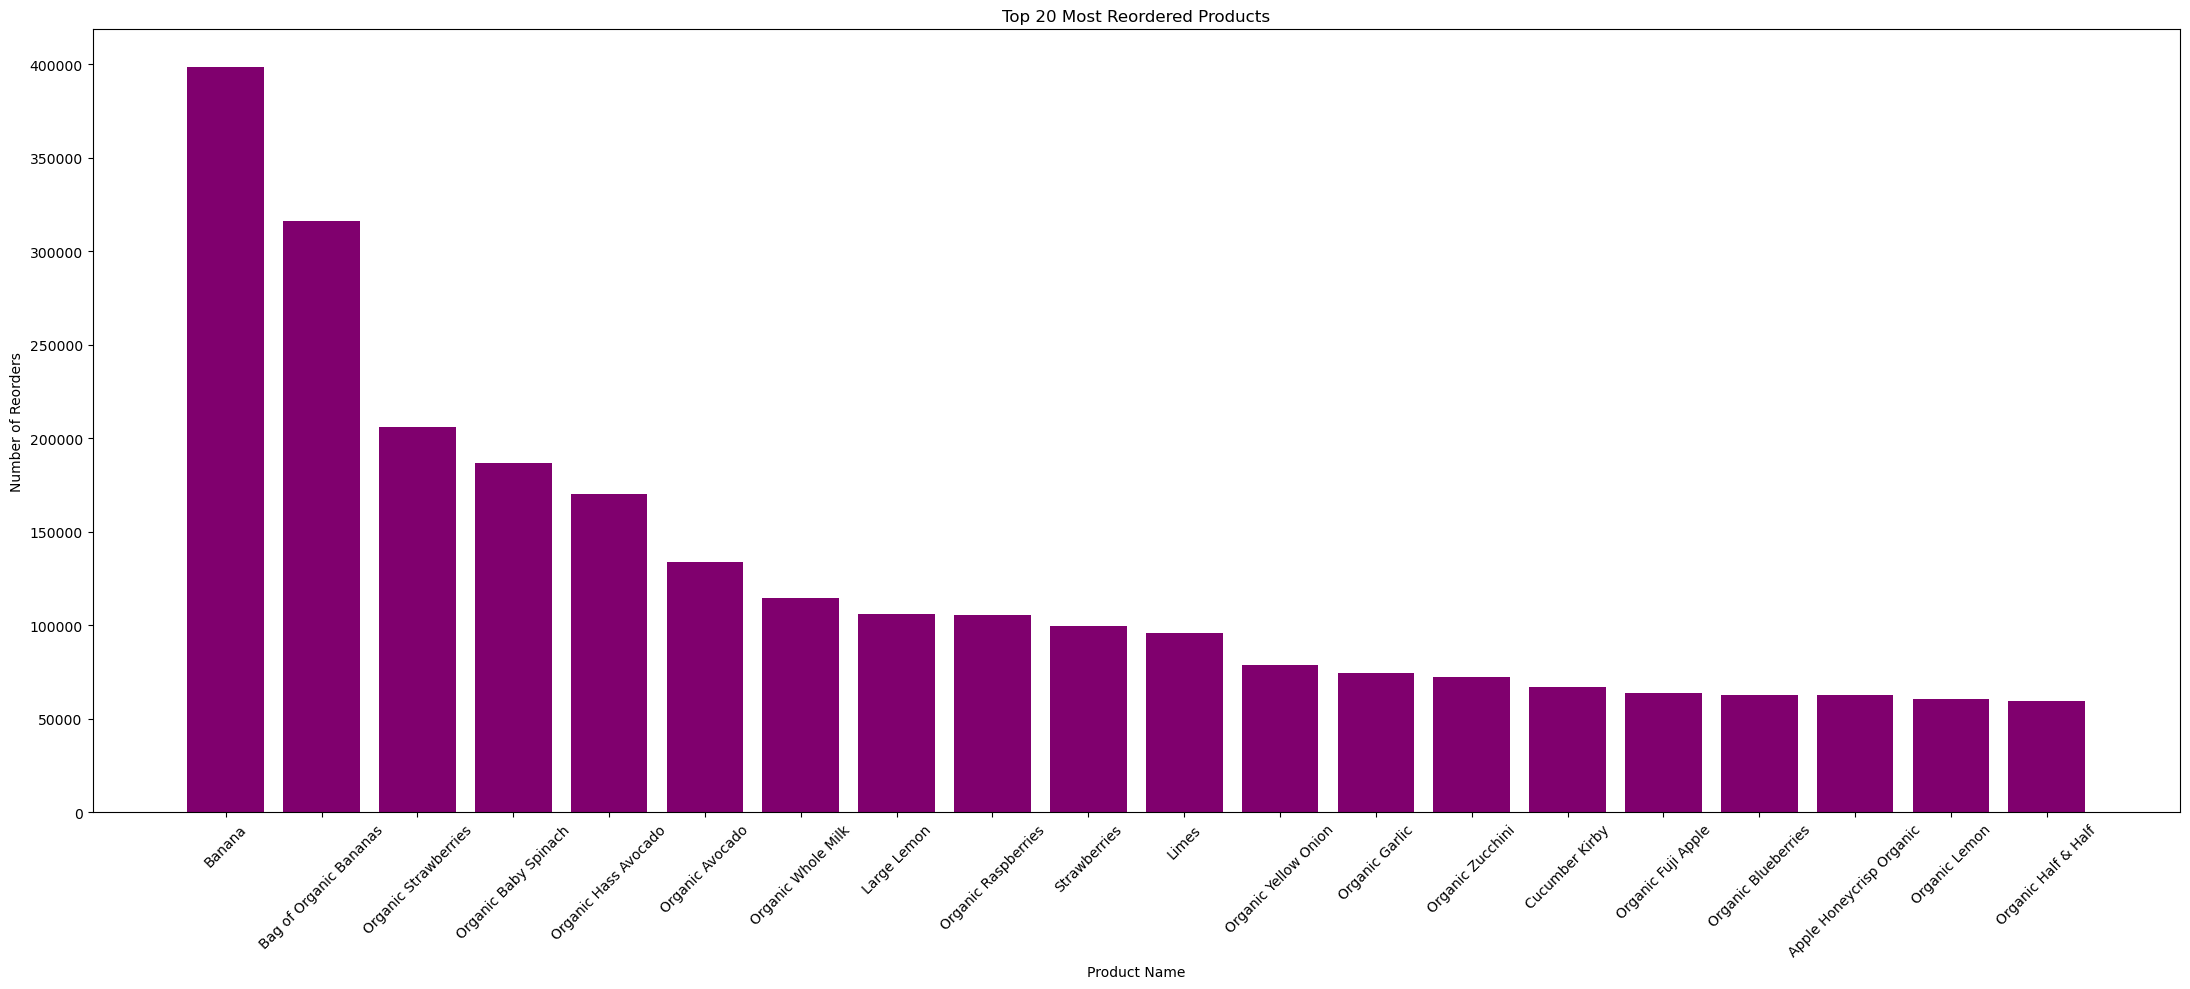

In [23]:
fig, ax = plt.subplots(figsize=(22, 10))
top20_reordered = most_reordered_products.head(20)
ax.bar(top20_reordered['product_name'], top20_reordered['reordered'], color="#80006E")
ax.set_xlabel('Product Name')
ax.set_ylabel('Number of Reorders')
ax.set_title('Top 20 Most Reordered Products')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 6. Average Basket size (number of items per order)

In [24]:
combined_order_items = pd.concat(
    [order_items__prior, order_items__train],
    ignore_index=True
)
# Step 1: Compute basket size per product (average number of items in orders where the product appears)

# Count how many items each order has
basket_sizes = combined_order_items.groupby('order_id').size().rename('basket_size')

# Merge basket size back to each product-order row
items_with_basket = combined_order_items.merge(
    basket_sizes, on='order_id', how='left'
)

# Step 2: Compute average basket size per product
avg_basket_size_per_product_df = (
    items_with_basket.groupby('product_id')['basket_size']
    .mean()
    .reset_index()
    .merge(product_catalog[['product_id','product_name']], on='product_id', how='left')
    .rename(columns={'basket_size':'Average Basket Size'})
)

MemoryError: Unable to allocate 258. MiB for an array with shape (33819106,) and data type int64

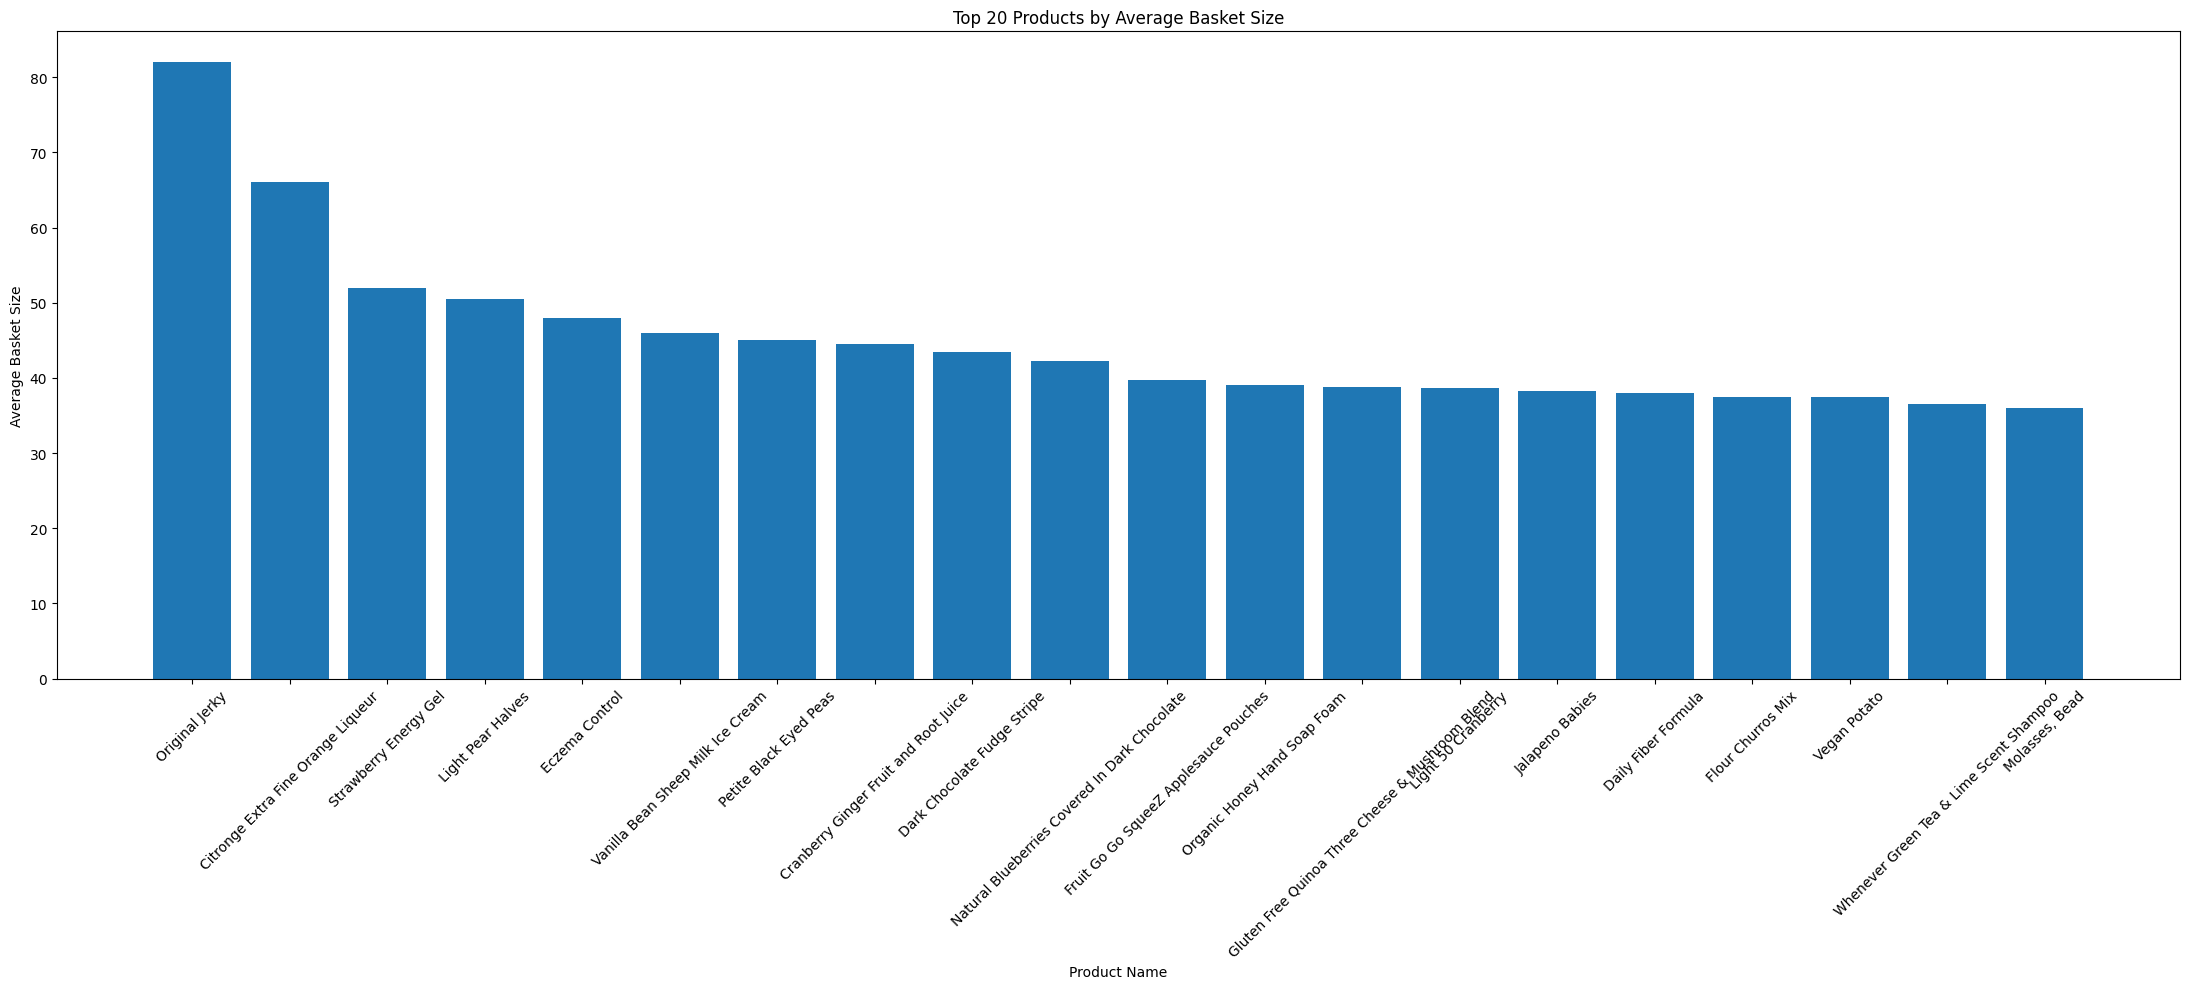

In [ ]:
top_avg_basket_products = avg_basket_size_per_product_df.sort_values(
    by="Average Basket Size", ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(22, 10))
top20_avg_basket = top_avg_basket_products.head(20)
ax.bar(top20_avg_basket['product_name'], top20_avg_basket['Average Basket Size'], color="#1f77b4")
ax.set_xlabel('Product Name')
ax.set_ylabel('Average Basket Size')
ax.set_title('Top 20 Products by Average Basket Size')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 7. Order trends by hour of the day, day of the week, and days since prior order.

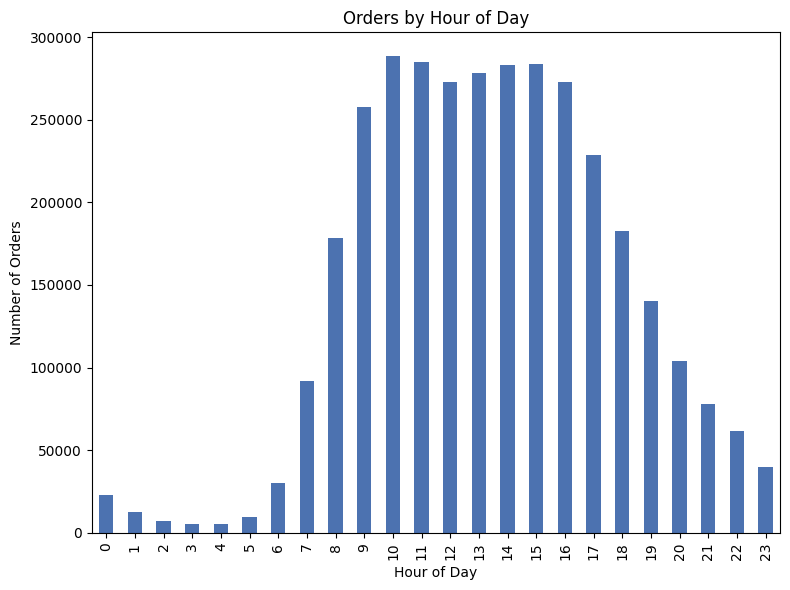

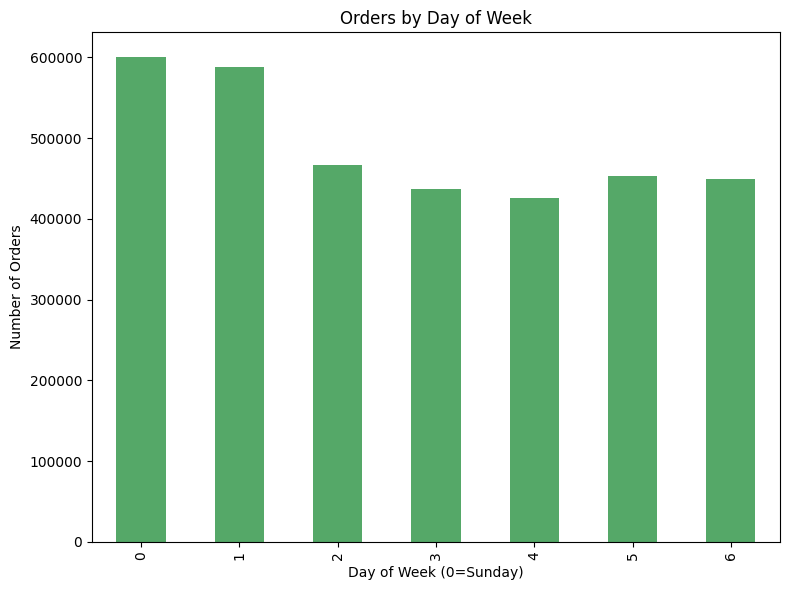

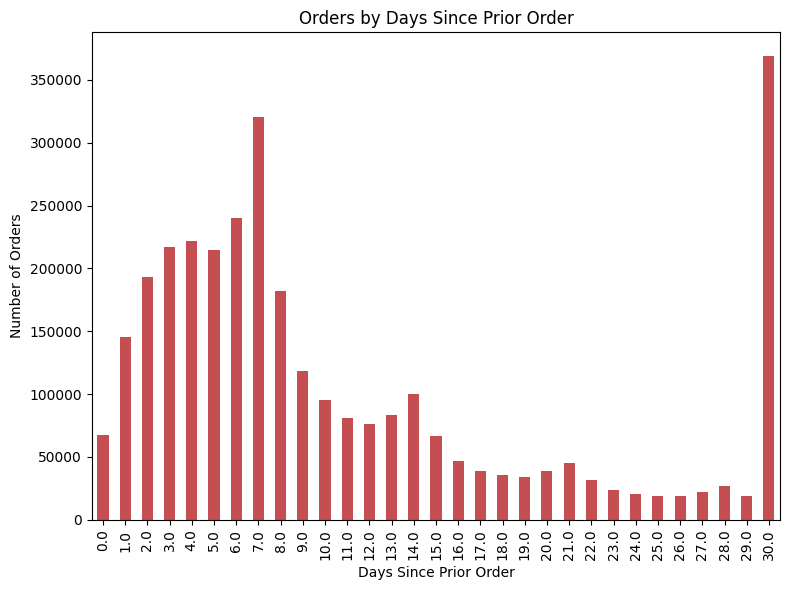

In [ ]:
fig1, ax1 = plt.subplots(figsize=(8, 6))
order_metadata['order_hour_of_day'].value_counts().sort_index().plot(
    kind='bar', ax=ax1, color='#4C72B0'
)
ax1.set_title('Orders by Hour of Day')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
order_metadata['order_dow'].value_counts().sort_index().plot(
    kind='bar', ax=ax2, color='#55A868'
)
ax2.set_title('Orders by Day of Week')
ax2.set_xlabel('Day of Week (0=Sunday)')
ax2.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

fig3, ax3 = plt.subplots(figsize=(8, 6))
order_metadata['days_since_prior_order'].dropna().value_counts().sort_index().plot(
    kind='bar', ax=ax3, color='#C44E52'
)
ax3.set_title('Orders by Days Since Prior Order')
ax3.set_xlabel('Days Since Prior Order')
ax3.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()


## Task 2: Understanding Customer Buying Patterns using Product Combination Analysis

In [ ]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\Shubh Sareen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

# Prepare the transaction dataset
# Merge order_items_prior/train with product_catalog to get product names
order_products = pd.concat([order_items__prior, order_items__train], ignore_index=True)
order_products = order_products.merge(product_catalog, on="product_id", how="left")

# Keep only top 100 most frequently ordered products
top_products = (order_products['product_name']
                .value_counts()
                .head(100)
                .index)

order_products = order_products[order_products['product_name'].isin(top_products)]

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [ ]:
warnings.filterwarnings("ignore", message=".*datetime.datetime.utcnow().*")

In [ ]:
# Create order-product binary matrix
basket = pd.crosstab(order_products['order_id'], order_products['product_name'])

# Convert values >0 into 1 (binary encoding for presence/absence)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

C:\Users\Shubh Sareen\AppData\Local\Temp\ipykernel_14084\2690971648.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


In [ ]:
# Build a product co-occurrence table (pairs appearing in the same order)
from itertools import combinations

# group products by order and take unique product names per order
order_products_per_order = order_products.groupby('order_id')['product_name'].unique()

pair_counts = {}
for products in order_products_per_order:
    if len(products) < 2:
        continue
    # sort products so (A, B) and (B, A) are treated the same
    for a, b in combinations(sorted(products), 2):
        pair_counts[(a, b)] = pair_counts.get((a, b), 0) + 1

# Convert to DataFrame
pairs_df = pd.DataFrame([{'product_a': a, 'product_b': b, 'count': c} for (a, b), c in pair_counts.items()])

# If there are no pairs (guard) create empty dataframe structure
if pairs_df.empty:
    pairs_df = pd.DataFrame(columns=['product_a', 'product_b', 'count', 'support'])
else:
    # compute support relative to number of orders considered
    n_orders_considered = order_products['order_id'].nunique()
    pairs_df['support'] = pairs_df['count'] / n_orders_considered
    pairs_df = pairs_df.sort_values('count', ascending=False).reset_index(drop=True)

# Top 20 combinations
top20_pairs = pairs_df.head(100)

# Display top 20
print(f'Number of orders considered: {order_products["order_id"].nunique()}')
# show a readable table and save results
if not top20_pairs.empty:
    from IPython.display import display
    display(top20_pairs)
    top20_pairs.to_csv('top100_product_pairs.csv', index=False)
    print("Saved top 100 pairs to top20_product_pairs.csv")
else:
    print('No product pairs found')

Number of orders considered: 2444982


,product_a,product_b,count,support
0,Bag of Organic Bananas,Organic Hass Avocado,64761,0.026487
1,Bag of Organic Bananas,Organic Strawberries,64702,0.026463
2,Banana,Organic Strawberries,58330,0.023857
3,Banana,Organic Avocado,55611,0.022745
4,Banana,Organic Baby Spinach,53395,0.021839
...,...,...,...,...
95,Organic Large Extra Fancy Fuji Apple,Organic Strawberries,15763,0.006447
96,100% Whole Wheat Bread,Banana,15746,0.006440
97,Large Lemon,Organic Hass Avocado,15738,0.006437
98,Asparagus,Banana,15738,0.006437


Saved top 20 pairs to top20_product_pairs.csv


Summary:
- The strongest product pairings are dominated by fresh produce. Top combinations by absolute co‑occurrence (and support) are:
    - Bag of Organic Bananas + Organic Hass Avocado — 64,761 occurrences (~2.65% support)
    - Bag of Organic Bananas + Organic Strawberries — 64,702 occurrences (~2.65% support)
    - Banana + Organic Strawberries — 58,330 occurrences (~2.39% support)
    - Banana + Organic Avocado — 55,611 occurrences (~2.27% support)
    - Banana + Organic Baby Spinach — 53,395 occurrences (~2.18% support)
- Many other high‑rank pairs follow the same pattern: bananas (both regular and organic), berries (strawberries/raspberries/blueberries), avocados, and leafy greens co‑occur frequently.
- Support values are a few percent for top pairs, indicating these combinations appear in a meaningful fraction of orders among the ~2.44M orders considered.

Main takeaways:
- Bundling/placement: Bananas act as a central hub item — cross-merchandise bananas with avocados, strawberries and greens (endcaps, adjacent shelving, combo offers).
- Promotions: Feature fresh-produce combos (banana + berries, banana + avocado) in homepage banners and targeted promotions to drive incremental basket value.
- Inventory: Prioritize stock and replenishment for these produce clusters to avoid lost sales from co‑purchase demand.
- Personalization: Use these high-probability pairs in recommendation engines (e.g., “Customers who bought bananas also bought avocados/berries”) to increase cross‑sell.
- Category strategy: Produce-focused tactics (bundles, meal-kit suggestions, recipe-based marketing) will likely yield the best ROI given dominance of fresh items in top pairs.

### Task 3 — Business Recommendations

1. Inventory suggestions for high‑demand products
- Prioritize replenishment and higher safety stock for top sellers (examples from top_products / top20_reordered): Banana, Bag of Organic Bananas, Organic Strawberries, Organic Baby Spinach, Organic Hass Avocado, Organic Avocado, Organic Whole Milk, Organic Raspberries, Strawberries, Limes.
- Apply category-level priorities: produce and dairy (top_departments) should have faster replenishment cycles and shorter reorder intervals.
- Set dynamic safety stock proportional to (a) weekly sales velocity, (b) reorder frequency, and (c) supplier lead time. For fastest movers, target safety stock = 2–4× lead‑time demand.
- Monitor products with high average basket size (top_avg_basket_products) for potential shelving/fulfillment /packaging adjustments (bulk packing, larger case sizes) to reduce unit handling cost and stockouts.
- Use automated alerts for inventory dips on items appearing frequently in high‑value combos (pairs_df top pairs) to avoid losing cross‑sell conversions.

2. Ideas for product bundling (based on association rules / top20_pairs)
- Promote frequent co‑purchases as ready bundles: e.g., Banana + Avocado, Bag of Organic Bananas + Organic Hass Avocado, Banana + Organic Strawberries, Banana + Organic Baby Spinach.
- Bundle formats: fixed‑price combos, “buy 1 get 1 at X%” for complementary items, and recipe/meal kits combining tightly co‑occurring items (fruit + greens + dressing).
- Merchandising: place high‑cooccurrence items adjacent in store UI or physically (endcaps, adjacent shelves) and highlight them in “Frequently Bought Together.”
- Personalization: use association rules to serve in‑session recommendations (antecedent → consequent) with confidence/lift thresholds for reliability.
- Test bundles via A/B experiments and promote top performers across email, app banners, and checkout upsell.

3. Suggested times for sending promotional notifications (based on peak ordering times)
- Target notifications around peak order windows derived from order_hour_of_day and order_dow (use the computed peak_hours / peak_days slices). Key windows: During peak hours (10am to 4pm) and early morning for daily groceries.
- Practical schedule suggestions: send a first wave 1–2 hours before the highest morning peak and a second wave 30–60 minutes before the main evening peak. (Implement schedule using the exact peak_hours identified in the notebook.)
- Weekly notifications can be sent on Friday and Saturdays, catering to the Sunday peaks every week. Similarly Monthly notications can be sent after 28 days of last purchase, catering to the large peak at day 30.
- Use segmentation and frequency caps: high‑value customers get earlier/personalized offers; low‑engagement customers receive fewer, more targeted pushes.
- Include urgency and contextual content (limited‑time bundle, low‑stock alert for favorites) to increase CTR and conversion in peak windows.

4. Recommendations for featured products in the app homepage / banners
- Feature a mix: (A) top demand items (from top_products / top20_reordered) and (B) high‑lift consequents from association rules (strong_rules). Example candidates: Banana, Bag of Organic Bananas, Organic Strawberries, Organic Hass Avocado, Organic Avocado, Organic Whole Milk, Organic Raspberries, Strawberries, Limes.
- Rotate banners weekly and A/B test combinations: single best-seller banner vs. “Bundle of the Week” (e.g., Banana + Strawberries + Avocado).
- Use contextual banners per time of day: breakfast‑focused products in morning, dinner/meal‑prep bundles in late afternoon.
- Track KPIs for each featured tile (impressions → CTR → add‑to‑cart → conversion) and reallocate prime homepage space to tiles that show positive lift within 7–14 days.

Action items:
- Implement automated dashboards for top SKUs, co‑occurrence pairs, and hourly order trends.
- Run small pilot bundle promotions for the top 5 pairs and measure uplift.
- Configure notification scheduler to use computed peak_hours/peak_days and monitor lift by cohort.